100 equilibria, use one free parameter combination (or maybe 5) and then run the EPEDNN loop and make a plot of pressure predicted vs. pfile pressure at psiN=1-delta and psiN=0.85

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

ROOT = Path.cwd().parent.parent
sys.path.insert(0, str(ROOT))
from src.profiles_loop_solve import profiles_loop_solve
from src.load_equil import initialize_inputs

from OpenFUSIONToolkit.TokaMaker.util import read_eqdsk

Authorization required, but no authorization protocol specified
Authorization required, but no authorization protocol specified


In [7]:
verbose = True

# Output data and files
ne_success_fp = 'success_profloop'

# Scan parameters
x_res = 20
eped_tol_max = 1e-5
free_params = {
    'alpha_crit': 0.1,
    'C_KBM': 1,
    'De_chie_etg': 0.1,
    'nFC_x0': 3.16228e15,
    'ncx_x0_ratio': 17.783
}

# Equilibria parameters
equil_num = 2
kprof_loc = 'pfile'
geqdsk_dir = Path('/mnt/homes_global/jal2351/software/sc_inputs/CAKEgeqdsks')
pfile_dir = Path('/mnt/homes_global/jal2351/software/sc_inputs/CAKEpfiles')
# geqdsk_dir = Path('/mnt/homes_global/jal2351/software/sc_inputs/gHighPerfHMode')
# pfile_dir = Path('/mnt/homes_global/jal2351/software/sc_inputs/OMFITnc_HighPerfHMode')
kbm_treatment = "picard"
kbm_gate_eps = 0.1
picard_gate_mode = "average"
picard_max_it = 50
picard_rtol = 1e-8
picard_relax = 1.0

In [8]:
# Load in equilibria
from collections import defaultdict
'''
def initialize_inputs(equil_num, geqdsk_dir=geqdsk_dir, pfile_dir=pfile_dir):
    """Select equil_num g/p file pairs from the CAKE input directories.

    Files are named g{shot}.{time} and p{shot}.{time}. Selection prioritizes
    one equilibrium per shot number before adding additional times from shots
    that already have a selected equilibrium.
    """
    geqdsk_dir = Path(geqdsk_dir)
    pfile_dir = Path(pfile_dir)

    g_by_suffix = {
        f.name[1:]: f for f in geqdsk_dir.glob("g*") if f.is_file()
    }
    p_by_suffix = {
        f.name[1:]: f for f in pfile_dir.glob("p*") if f.is_file()
    }
    shared_suffixes = sorted(set(g_by_suffix) & set(p_by_suffix))

    by_shot = defaultdict(list)
    for suffix in shared_suffixes:
        shot, time = suffix.split(".", 1)
        by_shot[shot].append((time, suffix))
    for shot in by_shot:
        by_shot[shot].sort()

    shots = sorted(by_shot)
    selected = []
    time_idx = 0
    while len(selected) < equil_num:
        added_this_round = False
        for shot in shots:
            if len(selected) >= equil_num:
                break
            entries = by_shot[shot]
            if time_idx < len(entries):
                suffix = entries[time_idx][1]
                selected.append(
                    (str(g_by_suffix[suffix]), str(p_by_suffix[suffix]))
                )
                added_this_round = True
        if not added_this_round:
            break
        time_idx += 1

    if len(selected) < equil_num:
        raise ValueError(
            f"Requested {equil_num} equilibria but only found {len(selected)} "
            f"matching g/p pairs in {geqdsk_dir} and {pfile_dir}"
        )

    print(f"Selected {len(selected)} g/p file pairs:")
    for mhd_fp, kprof_fp in selected:
        print(f"  g: {mhd_fp}\n  p: {kprof_fp}")
    return selected
'''
equilibria = initialize_inputs(equil_num, geqdsk_dir, pfile_dir, p_filetype=kprof_loc)

Selected 2 g/pfile file pairs:
  g: /mnt/homes_global/jal2351/software/sc_inputs/CAKEgeqdsks/g150840.03000
  p: /mnt/homes_global/jal2351/software/sc_inputs/CAKEpfiles/p150840.03000
  g: /mnt/homes_global/jal2351/software/sc_inputs/CAKEgeqdsks/g152960.03500
  p: /mnt/homes_global/jal2351/software/sc_inputs/CAKEpfiles/p152960.03500


In [9]:
MHD_FP = Path('/mnt/homes_global/jal2351/software/sc_inputs/CAKEgeqdsks/g158091.01935') # filepath to MHD paramter file
KPROF_FP = Path('/mnt/homes_global/jal2351/software/sc_inputs/CAKEpfiles/p158091.01935')
equilibria = [(MHD_FP, KPROF_FP)]

In [10]:
def pres_pred(ped_wid, gfile_pres, gfile_pres_grid):
    """
    Calculate pedestal pressure from pedestal width and MHD equilibrium file.
    """
    psiN_top = 1 - ped_wid
    return np.interp(psiN_top, gfile_pres_grid, gfile_pres)

/mnt/homes_global/jal2351/software/sc_inputs/CAKEgeqdsks/g158091.01935
Setting up EPEDNN...
Base model built.
betan: [1.20080331]
Pedestal height: 0.009909681784119016 MPa, Pedestal width: 0.03793067933607768 (psi_N)
  Te_ped = 1054.3 eV, T_sep = 155.1 eV (ne_ped = 2.933e+19 m^-3, psi_ped = 0.9621, Delta = 0.0379)
  psi_N_inner_boundary_new = 0.9621
Setting up EPEDNN...
betan: [1.48966948]
Pedestal height: 0.009618833233268582 MPa, Pedestal width: 0.03743645833109204 (psi_N)
Normalized pedestal pressure height and width tolerance: -0.04237952334730256
  Te_ped = 949.9 eV, T_sep = 155.1 eV (ne_ped = 3.160e+19 m^-3, psi_ped = 0.9626, Delta = 0.0374)
  psi_N_inner_boundary_new = 0.9626
Setting up EPEDNN...
betan: [1.49681724]
Pedestal height: 0.0097479865943501 MPa, Pedestal width: 0.037625911593883156 (psi_N)
Normalized pedestal pressure height and width tolerance: 0.018487795845586318
  Te_ped = 929.2 eV, T_sep = 155.1 eV (ne_ped = 3.274e+19 m^-3, psi_ped = 0.9624, Delta = 0.0376)
  psi

KeyboardInterrupt: 

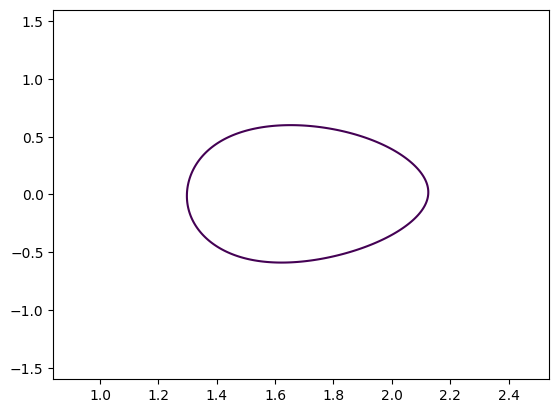

In [11]:
# For each equilbrium, call profiles_loop_solve() from profiles_loop_solve.py
failed=[]
success=[]
for mhd_fp, kprof_fp in equilibria:
    # try:
        print(mhd_fp)
        ped_wid, ped_h_out, gfile_pres, gfile_pres_grid = profiles_loop_solve(
            MHD_FP = mhd_fp,
            kprof_loc = kprof_loc,
            KPROF_FP = kprof_fp,
            ne_success_fp = ne_success_fp,
            x_res = x_res,
            eped_tol_max = eped_tol_max,
            free_params = free_params,
            kbm_treatment = kbm_treatment,
            kbm_gate_eps = kbm_gate_eps,
            picard_gate_mode = picard_gate_mode,
            picard_max_it = picard_max_it,
            picard_rtol = picard_rtol,
            picard_relax = picard_relax,
            verbose = verbose,
        )
        p_gfile = pres_pred(ped_wid, gfile_pres, gfile_pres_grid)
        out_dict = {
            'mhd_fp': mhd_fp,
            'kprof_fp': kprof_fp,
            'ped_h': ped_h_out,
            'ped_wid': ped_wid,
            'p_gfile': p_gfile,
        }
        success.append(out_dict)
    # except Exception as e:
    #     failed.append(mhd_fp)

In [ ]:
# Plot pressure predicted (p_out) vs. geqdsk pressure at psiN=1-delta and psiN=0.85 for all equilibria
fig, ax = plt.subplots()
for out_dict in success:
    ax.plot(out_dict['p_gfile'] / 1e6, out_dict['ped_h'],'o')
ax.plot([0, 0.015], [0, 0.015], 'k--')
ax.set_xlabel('GEQDSK pressure [MPa]')
ax.set_ylabel('Predicted pressure [MPa]')